In [1]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import skimage as ski
import matplotlib.pyplot as plt
import skimage as ski

from image_utils import *

In [2]:
img_dir = os.path.join("iapr-26-uno-vision-challenge", "train_images")
annotations_file = os.path.join("iapr-26-uno-vision-challenge", "train") + '.csv'
annotations = pd.read_csv(annotations_file)

In [3]:
def determine_case(img, thresh=200):
    return int(np.mean(img) < thresh)

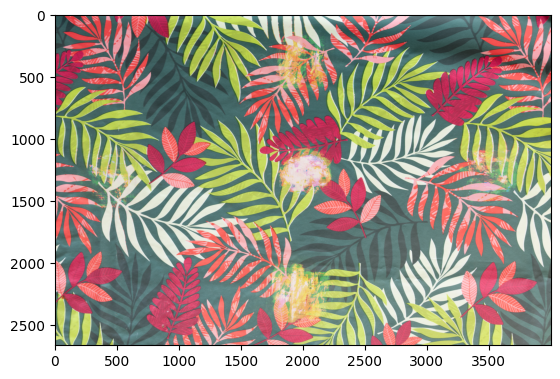

In [4]:
def generate_backgound_image():
    images_case1 = []
    for image_id in annotations['image_id']:
        image_path = os.path.join(img_dir, image_id) + '.jpg'
        img = load_image(image_path, display=False)
        if (determine_case(img) == 1):
            images_case1.append(img)
    return np.median(np.array(images_case1), axis=0).astype(np.uint8)

background_img = generate_backgound_image()
plt.imshow(background_img)
plt.show()

In [5]:
def fade_background(img, background, threshold=0.02):
    if (determine_case(img) == 0):
        return img
    img_hsv = ski.color.rgb2hsv(img.copy())
    background_hsv = ski.color.rgb2hsv(background.copy())
    absolute_diff_img = np.abs(img_hsv[:,:,0] - background_hsv[:,:,0])
    background_mask = (absolute_diff_img < threshold)
    img_modified = img.copy()
    img_modified[background_mask] = 255
    return img_modified

In [6]:
image_path = get_random_imagepath(img_dir, annotations)

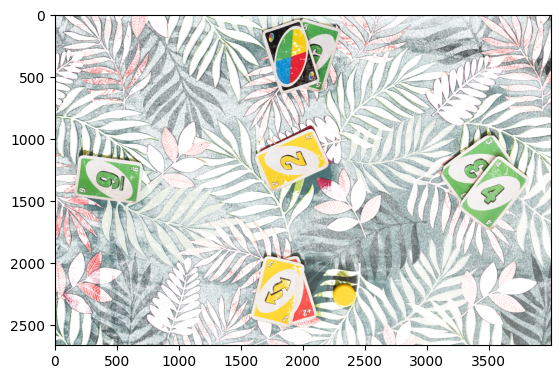

In [7]:
img = load_image(image_path, display=False)
img_fade_background = fade_background(img, background_img, threshold=0.015)
plt.imshow(img_fade_background)
plt.show()

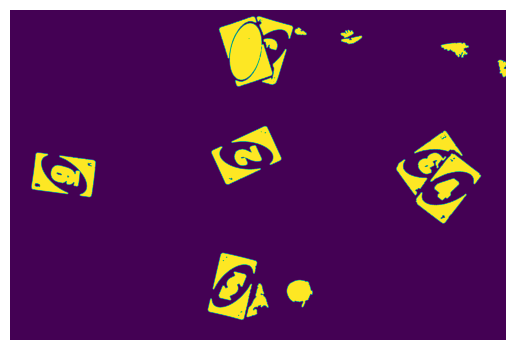

In [8]:
mask = card_mask(img_fade_background)

plt.imshow(mask)  
plt.axis('off')
plt.show()

In [11]:
def remove_background(img, background):
    img = img.copy()
    img_fade_background = fade_background(img, background)
    background_mask = np.logical_not(card_mask(img_fade_background))
    img[background_mask] = 255
    return img

img_without_background = remove_background(img, background_img)

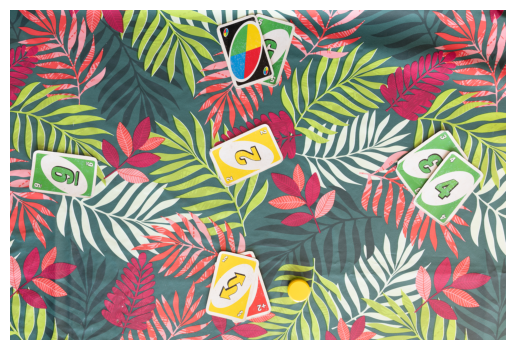

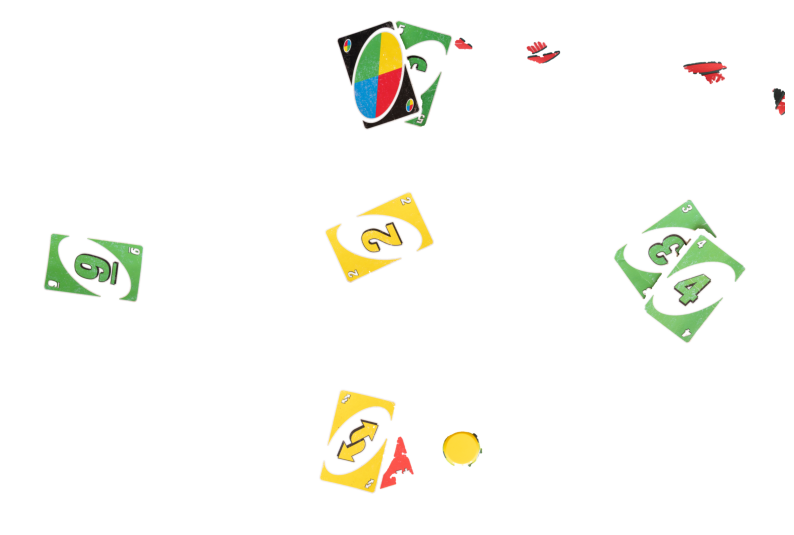

In [14]:
plt.imshow(img)  
plt.axis('off')
plt.show()

plt.figure(figsize=(10,10))
plt.imshow(img_without_background)  
plt.axis('off')
plt.show()